In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
import itertools
import os
import anndata as ad

In [2]:
sam_mg = SAM()
sam_mg.load_data('../../Subclustering/PVH/SAM_Allen_Institute_PVH.h5ad')

sam_mo = SAM()
sam_mo.load_data('../../Subclustering/PVH/SAM_MO_soupx_plus5_cleaned_PVH_07282026.h5ad')

sam_cj = SAM()
sam_cj.load_data('../../Subclustering/PVH/SAM_CJ_joined_v2_cleaned_03122025_PVH.h5ad')

sam_ac = SAM()
sam_ac.load_data('../../Subclustering/PVH/SAM_AC_ncbi_soupx_cleaned_PVH_03122025.h5ad')

sam_xt = SAM()
sam_xt.load_data('../../Subclustering/PVH/SAM_XT_joined_Slc17a6_cleaned_03122205_PVH.h5ad')

sam_dr = SAM()
sam_dr.load_data('../../Subclustering/PVH/SAM_DR_cleaned_PVH_07172026.h5ad')

In [3]:
sam_mo.adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,n_counts,n_genes,key,subclass_id_label_mapping,subclass_id_label_lc,leiden_clusters,subclass_id_label_mapping_nounlabeled,...,eq_subclass_nounlabeled,NN,ss_subclass,ss_subclass_nounlabeled,ss_subclass_nounlabeled_03102026,ss_subclass_nounlabeled_03102026_crossed,neurotransmitter_v2,test,eq_supertype_v3,clusters_v3
AAAGGGCAGTAGATCA,MO,3263.0,1783,3263.0,1783,Run12_sample1,133 PVH-SO-PVa Otp Glut,26,0,133 PVH-SO-PVa Otp Glut,...,133 PVH-SO-PVa Otp Glut,Neuron,133 PVH-SO-PVa Otp Glut,133 PVH-SO-PVa Otp Glut,133 PVH-SO-PVa Otp Glut,133 PVH-SO-PVa Otp Glut,Glut,Avp,Avp,0
AACCTTTCAAAGACGC,MO,8636.0,3382,8636.0,3382,Run12_sample1,133 PVH-SO-PVa Otp Glut,43,1,133 PVH-SO-PVa Otp Glut,...,133 PVH-SO-PVa Otp Glut,Neuron,133 PVH-SO-PVa Otp Glut,133 PVH-SO-PVa Otp Glut,133 PVH-SO-PVa Otp Glut,133 PVH-SO-PVa Otp Glut,Glut,Oxt,Oxt,1
AAGCATCAGTGTTGAA,MO,6444.0,3086,6444.0,3086,Run12_sample1,133 PVH-SO-PVa Otp Glut,273,6,133 PVH-SO-PVa Otp Glut,...,133 PVH-SO-PVa Otp Glut,Neuron,133 PVH-SO-PVa Otp Glut,133 PVH-SO-PVa Otp Glut,133 PVH-SO-PVa Otp Glut,133 PVH-SO-PVa Otp Glut,Glut,Nkx2-2,Nkx2-2,6
AAGTCGTGTCCTCAGG,MO,5084.0,2744,5084.0,2744,Run12_sample1,133 PVH-SO-PVa Otp Glut,26,0,133 PVH-SO-PVa Otp Glut,...,133 PVH-SO-PVa Otp Glut,Neuron,133 PVH-SO-PVa Otp Glut,133 PVH-SO-PVa Otp Glut,133 PVH-SO-PVa Otp Glut,133 PVH-SO-PVa Otp Glut,Glut,Avp,Avp,0
ACAGAAAGTATGATCC,MO,4091.0,2409,4091.0,2409,Run12_sample1,133 PVH-SO-PVa Otp Glut,486,7,133 PVH-SO-PVa Otp Glut,...,133 PVH-SO-PVa Otp Glut,Neuron,133 PVH-SO-PVa Otp Glut,133 PVH-SO-PVa Otp Glut,133 PVH-SO-PVa Otp Glut,133 PVH-SO-PVa Otp Glut,Glut,Sst,Sst,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTCGGTCCAGCTATTG,MO,3640.0,2067,3640.0,2067,Run12_sample12,133 PVH-SO-PVa Otp Glut,26,0,133 PVH-SO-PVa Otp Glut,...,133 PVH-SO-PVa Otp Glut,Neuron,133 PVH-SO-PVa Otp Glut,133 PVH-SO-PVa Otp Glut,133 PVH-SO-PVa Otp Glut,133 PVH-SO-PVa Otp Glut,Glut,Avp,Avp,0
TTCGGTCCAGGCATTT,MO,11289.0,3651,11289.0,3651,Run12_sample12,133 PVH-SO-PVa Otp Glut,43,4,133 PVH-SO-PVa Otp Glut,...,133 PVH-SO-PVa Otp Glut,Neuron,133 PVH-SO-PVa Otp Glut,133 PVH-SO-PVa Otp Glut,133 PVH-SO-PVa Otp Glut,133 PVH-SO-PVa Otp Glut,Glut,Oxt,Oxt,4
TTGGGTACAGTTGGTT,MO,4043.0,2339,4043.0,2339,Run12_sample12,133 PVH-SO-PVa Otp Glut,266,2,133 PVH-SO-PVa Otp Glut,...,133 PVH-SO-PVa Otp Glut,Neuron,133 PVH-SO-PVa Otp Glut,133 PVH-SO-PVa Otp Glut,133 PVH-SO-PVa Otp Glut,133 PVH-SO-PVa Otp Glut,Glut,Nkx2-2,Nkx2-2,2
TTGTTTGCACCGTGAC,MO,2465.0,1681,2465.0,1681,Run12_sample12,133 PVH-SO-PVa Otp Glut,574,9,133 PVH-SO-PVa Otp Glut,...,133 PVH-SO-PVa Otp Glut,Neuron,133 PVH-SO-PVa Otp Glut,133 PVH-SO-PVa Otp Glut,133 PVH-SO-PVa Otp Glut,133 PVH-SO-PVa Otp Glut,Glut,Crh,Crh,9


In [4]:
sam_mg.adata.obs['eq_supertype_v3'] = sam_mg.adata.obs['eq_supertype']

In [5]:
all_sup = set(sam_mg.adata.obs['eq_supertype_v3'].unique()) | set(sam_mo.adata.obs['eq_supertype_v3'].unique()) | set(sam_cj.adata.obs['eq_supertype_v3'].unique()) | set(sam_ac.adata.obs['eq_supertype_v3'].unique()) | set(sam_xt.adata.obs['eq_supertype_v3'].unique()) | set(sam_dr.adata.obs['eq_supertype_v3'].unique()) 

In [6]:
color_map_two = {'Avp':'#4FAE49',
                   'Crh': '#F37F20',
                   'Nkx2-2':'#83C6DB',
                   'Oxt':'#E12228',
                   'Sst':'#EC82B3',
                   'Trh':'#98509F',
                   'Ucn3':'#F6EC39'}

In [7]:
sam_cj.adata.obs['eq_supertype_v3'].unique()

['Avp', 'Nkx2-2', 'Oxt', 'Crh', 'Sst', 'Trh']
Categories (6, object): ['Avp', 'Crh', 'Nkx2-2', 'Oxt', 'Sst', 'Trh']

In [8]:
sam_xt.adata.obs['eq_supertype_v2']

AACCCAAGTTAATGAG Run19_sample1    Nkx2-2
AACCTGAAGCCTCAGC Run19_sample1    Nkx2-2
AACTTCTAGAACTGAT Run19_sample1    Nkx2-2
AAGTGAACAGAACTTC Run19_sample1    Nkx2-2
ACAAGCTTCCTCTTTC Run19_sample1       Avp
                                   ...  
TTCGATTTCGAGGCAA Run19_sample8       Crh
TTCTTCCAGCGTCTCG Run19_sample8       Sst
TTGGGATGTAGGATAT Run19_sample8       Crh
TTTACCACAGGCATGA Run19_sample8       Sst
TTTCACAGTACCTTCC Run19_sample8       Avp
Name: eq_supertype_v2, Length: 593, dtype: category
Categories (6, object): ['Avp', 'Crh', 'Nkx2-2', 'Oxt', 'Sst', 'Trh']

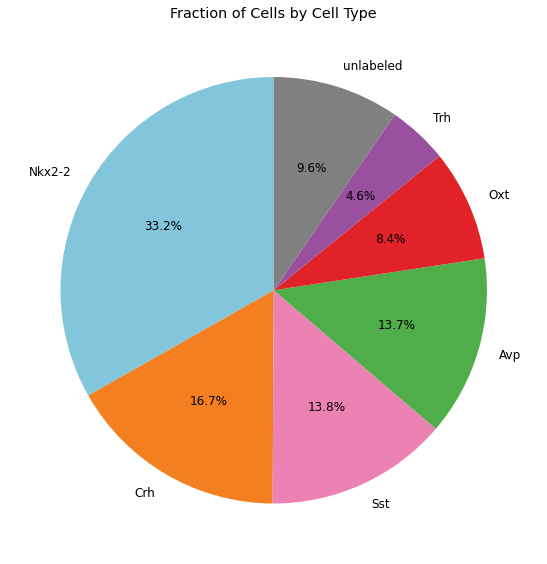

In [14]:
plt.rcParams['font.size'] = 12
level = 'eq_supertype_v3'
counts = sam_xt.adata.obs[level].value_counts()

known = counts[counts.index.isin(color_map_two)]
unknown_total = counts[~counts.index.isin(color_map_two)].sum()

if unknown_total > 0:
    known["unlabeled"] = unknown_total

labels = known.index
colors = [color_map_two.get(ct, "#808080") for ct in known.index]

plt.figure(figsize=(8, 8))
plt.pie(known.values,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors)

plt.title('Fraction of Cells by Cell Type')
plt.tight_layout()
plt.savefig('../../Figures/Figures_07242026/XT_PVH_cellfrac_piechart_07282026.svg',bbox_inches='tight')
plt.savefig('../../Figures/Figures_07242026/XT_PVH_cellfrac_piechart_07282026.pdf',bbox_inches='tight')
plt.show()